# Rating Curve Assessment
ANALYST NAME | DATE

This notebook is used to plot stage-Q data from the period with unprocessed levelogger data against the previously developed rating curves to see if the rating curves still capture the relationship between stage and Q properly (i.e. check if the rating curves need to be updated). 

Author of Template and Underlying Code: Joe Ammatelli | (jamma@uw.edu) | August 2022

## Import Libraries
**Analyst TODO**: Run cell

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import sys

sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import config_new_chatGPT

sys.path.remove(os.path.abspath(os.path.join('..', 'src')))

## Configure Plotting Preferences
**Analyst TODO:**
* Choose plotting backend:
    - Interactive (recommended): uncomment `%matplotlib notebook` and `FIGSIZE=NONE`; comment out `FIGSIZE = config.FIGSIZE`
    - Inline: comment out `%matplotlib notebook` `FIGSIZE=NONE`; uncomment `FIGSIZE = config.FIGSIZE`

In [2]:
%matplotlib notebook
sns.set_theme()

## Define Utility Functions
**Analyst TODO:** Run cells

In [ ]:
def plot_rating_curve(ax, site, hrange):
    ax.set_title('Rating Curve for ' + config_new_chatGPT.SITE_LONGNAME[site])
    ax.set_ylabel('Stage (m)')
    ax.set_xlabel('Q (m^3s^-1)')
    
    h = np.linspace(hrange[0], hrange[1], 100)
    Q = [config_new_chatGPT.RATING_CURVES[site](hi) for hi in h]
    
    ax.plot(Q, h, label='rating curve')
    ax.legend()

In [ ]:
def plot_site_stageQ(ax, site, stageQ, offset=0):
    site_stageQ = stageQ.loc[stageQ['Site Name'] == config_new_chatGPT.SITE_SHORTNAME[site]]    
    ax.scatter(site_stageQ['Measured Q (cms)'], site_stageQ['Stage (m)'] - offset, c='black', label='manual measurements')
    ax.legend()

## Load Stage/Q Data (all sites) for given span
**Analyst TODO**:
* Read data for each year of interest: add filename string to `fns` for each site
* Combine datasets into one dataframe
* convert units as necessary

In [5]:
# Read data for each year of interest
fns = ['tum_stageQ_2024.csv','tum_stageQ_2025.csv']  # add file name strings here (not full path, just name of file, e.g. 'TM_StageQ_2020.csv')
dfs = []

for fn in fns:
    path = os.path.join('..', 'compiled_data', 'stageQ', fn)
    dfs.append(pd.read_csv(path))

# Combine datasets into one dataframe
stageQ = pd.concat(dfs, ignore_index=True)

# convert units as necessary
FT_TO_M = 0.3048
stageQ = stageQ.rename(columns={'Stage (ft)' :'Stage (m)'})
#RHallnan had to add the next line to conbert the dtype of Stage (m) to a float, it was an object.
stageQ['Stage (m)'] = pd.to_numeric(stageQ['Stage (m)'], errors='coerce')
stageQ['Stage (m)'] *= FT_TO_M

CFS_TO_CMS = 0.028316847
stageQ = stageQ.rename(columns={'Measured Q (cfs)' :'Measured Q (cms)'})
stageQ['Measured Q (cms)'] *= CFS_TO_CMS

# view dataframe
stageQ

,Site Name,Field visit date,Field task,Q Method,Stage (m),Measured Q (cms),Gage maintenance notes
0,Tuolumne@120,6/4/2024,Discharge,ADCP,1.709928,19.028921,Issues with ADCP - Power switch and bluetooth ...
1,Tuolumne@120,6/18/2024,Discharge,ADCP,1.222248,5.351884,NaN
2,Tuolumne@120,6/25/2024,Discharge,ADCP,1.322832,7.107529,NaN
3,Tuolumne@120,7/8/2024,Discharge,ADCP,0.941832,3.256437,NaN
4,Tuolumne@120,8/22/2024,Discharge,ADV,0.813816,0.340085,NaN
...,...,...,...,...,...,...,...
62,LyellBlwMaclure,6/18/2025,NaN,Rhodamine,2.313432,1.769520,NaN
63,LyellBlwMaclure,6/18/2025,NaN,Salt,2.316480,1.419524,NaN
64,LyellBlwMaclure,6/18/2025,NaN,Rhodamine,2.316480,1.827569,NaN
65,LyellBlwMaclure,9/4/2025,"Discharge, stage, datalogger & Levelogger down...",Salt,2.097024,0.307238,NaN


## For each site, plot rating curve and data points
**Analyst TODO** Plot site of interest (or for which valid rating curves exist)
* List the numeric site codes you wish to plot in the `sites` list
    * 0 : Lyell Below Maclure
    * 1 : Lyell Above Twin Bridges
    * 2 : Dana Fork at Bug Camp
    * 3 : Tuolumne River at Highway 120
    * 4 : Budd Creek
    * 5 : Delaney Above PCT
* For each site, add a tuple to the hranges list representing the lower and upper bound of h ranges to plot. The i'th entry of hranges should correspond to the i'th entry of sites

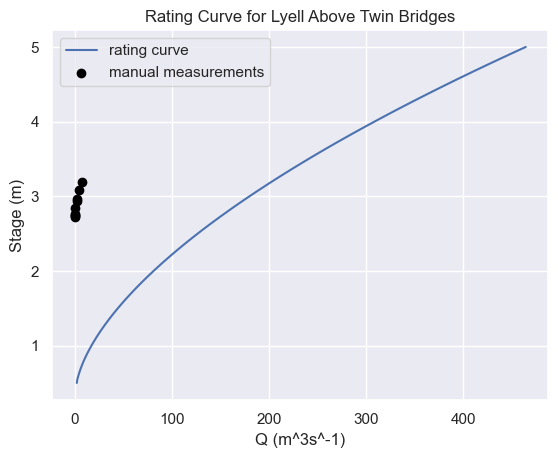

In [8]:
%matplotlib inline

# add sites here
# e.g. sites = [0, 1, 3]
sites = [1]

# add h ranges here
# e.g. hranges = [(1.8, 2.5), (0, 2), (0, 3)]
hranges = [(.5,5)]

for site, hrange in zip(sites, hranges):
    fig, ax = plt.subplots()
    plot_rating_curve(ax, site, hrange)
    plot_site_stageQ(ax, site, stageQ)
    plt.show()

In [7]:
ax.plot(Q, h)
print(Q[:10])

NameError: name 'Q' is not defined

## Conduct Site Specific Analysis
**Analyst TODO**: Complete site specific analysis as necessary